In [1]:
#Implementando bibliotecas
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
#definição do dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.3 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
img_transform = transforms.Compose([ #transformação de imagem
    transforms.ToTensor(), #converte a imagem em um tensor
    transforms.Normalize([0.5], [0.5]), #normalização
    transforms.Lambda(lambda x: x.to(device)) #transferência para o dispositivo
])

In [3]:
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.74MB/s]


In [5]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True) # treinamento
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False) # validacao

In [6]:
class AutoEncoder(nn.Module): #modelo autoencoder
    def __init__(self, latent_dim): #dimesão latente como parâmetro
        super().__init__()
        self.latent_dim = latent_dim
        #codificador
        self.encoder = nn.Sequential(
            nn.Linear(28*28,128), nn.ReLU(True), #O codificador coprime a imagem de entrada
            nn.Linear(128,64), nn.ReLU(True),
            nn.Linear(64,latent_dim))
        #decodificador
        self.decoder = nn.Sequential( # decodificador tenta reconstruir a imagem partir da representação latente
            nn.Linear(latent_dim,64),nn.ReLU(True),
            nn.Linear(64,128),nn.ReLU(True),
            nn.Linear(128,28*28),nn.Tanh())

    def forward(self,x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [8]:
# definir as funcoes para treinar e validar
def train_batch(input, model, optimizer, criterion):
    model.train()
    input = input.to(device)
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input) #perda do erro quadratico medio
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    input = input.to(device)
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.186  (28.96s - 115.84s remaining)
EPOCH: 2.000  trn_loss: 0.175  val_loss: 0.165  (54.19s - 81.28s remaining)
EPOCH: 3.000  trn_loss: 0.161  val_loss: 0.157  (80.16s - 53.44s remaining)
EPOCH: 4.000  trn_loss: 0.155  val_loss: 0.152  (107.45s - 26.86s remaining)
EPOCH: 5.000  trn_loss: 0.151  val_loss: 0.150  (129.87s - 0.00s remaining)


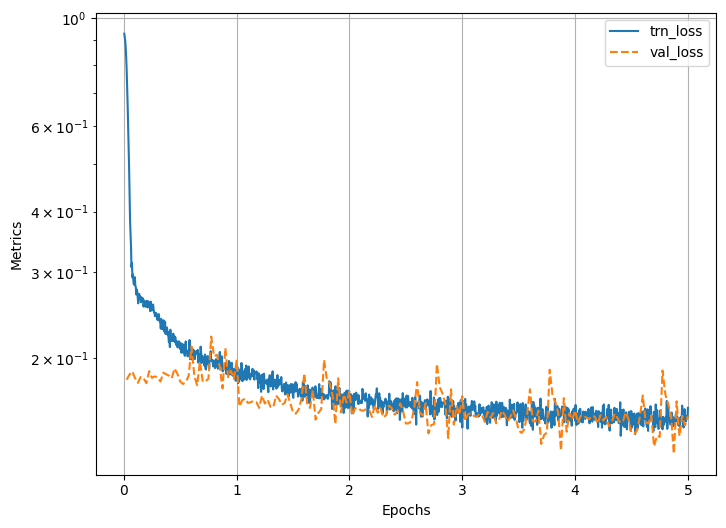

In [9]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5 #treina o autoencoder por 5 épocas
log = Report(num_epochs)

for epoch in range(num_epochs): #defini as perdas de treinamento e validação
  N = len(trn_dl)
  for ix, (data, _) in enumerate(trn_dl):
    loss = train_batch(data, model, optimizer, criterion)
    log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

  N = len(val_dl)
  for ix, (data, _) in enumerate(val_dl):
    loss = validate_batch(data, model, criterion)
    log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
  log.report_avgs(epoch+1)
log.plot(log=True)

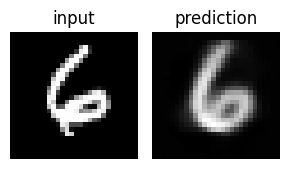

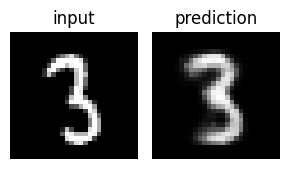

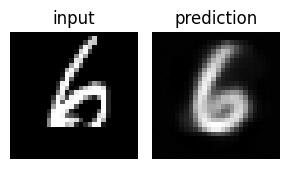

In [10]:
#agora é testa o autoencoder em algumas imagens
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.150  (24.95s - 99.79s remaining)
EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.150  (49.01s - 196.06s remaining)
EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.150  (73.23s - 292.92s remaining)
EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.150  (96.63s - 386.53s remaining)
EPOCH: 1.000  trn_loss: 0.248  val_loss: 0.150  (119.13s - 476.51s remaining)


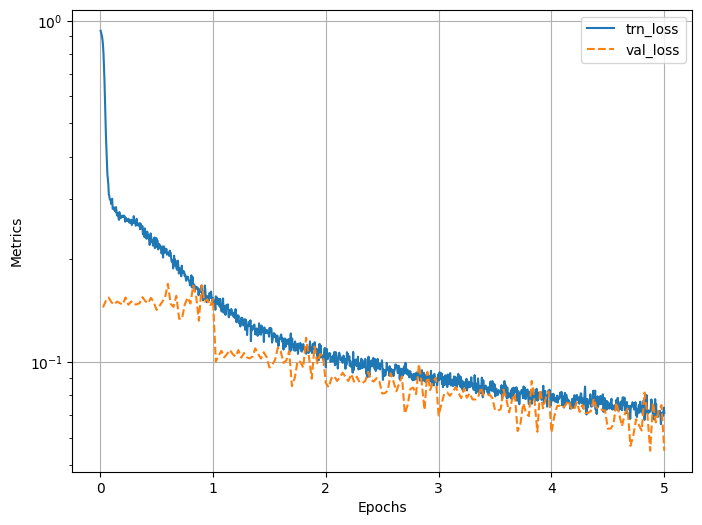

EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.207  (23.13s - 92.53s remaining)
EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.207  (46.32s - 185.29s remaining)
EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.207  (72.07s - 288.29s remaining)
EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.207  (97.44s - 389.74s remaining)
EPOCH: 1.000  trn_loss: 0.259  val_loss: 0.207  (120.92s - 483.70s remaining)


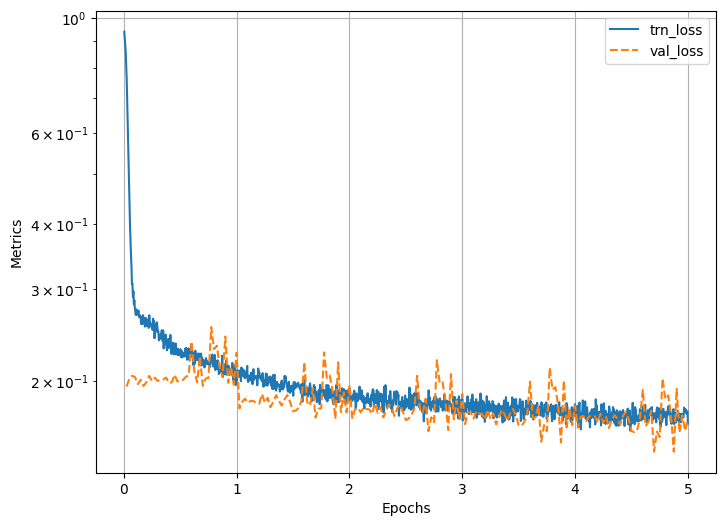

EPOCH: 1.000  trn_loss: 0.267  val_loss: 0.201  (21.31s - 85.23s remaining)
EPOCH: 1.000  trn_loss: 0.267  val_loss: 0.201  (43.93s - 175.72s remaining)
EPOCH: 1.000  trn_loss: 0.267  val_loss: 0.201  (68.01s - 272.04s remaining)
EPOCH: 1.000  trn_loss: 0.267  val_loss: 0.201  (91.35s - 365.39s remaining)
EPOCH: 1.000  trn_loss: 0.267  val_loss: 0.201  (113.20s - 452.82s remaining)


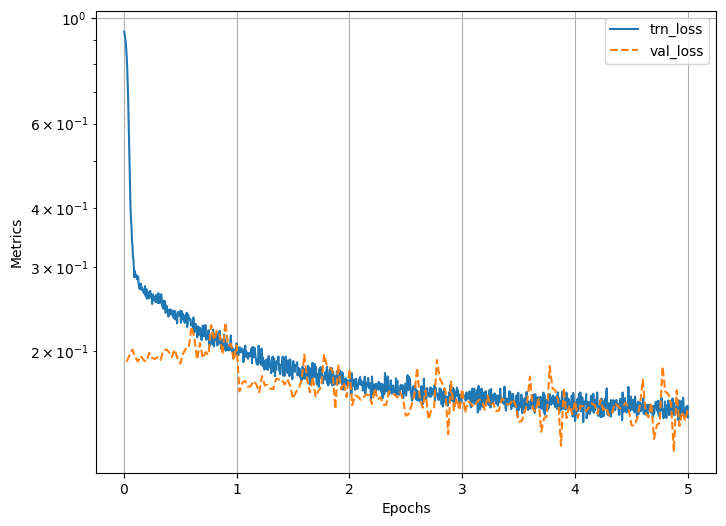

EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.175  (27.24s - 108.97s remaining)
EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.175  (50.53s - 202.10s remaining)
EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.175  (74.11s - 296.46s remaining)
EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.175  (96.13s - 384.52s remaining)
EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.175  (119.09s - 476.35s remaining)


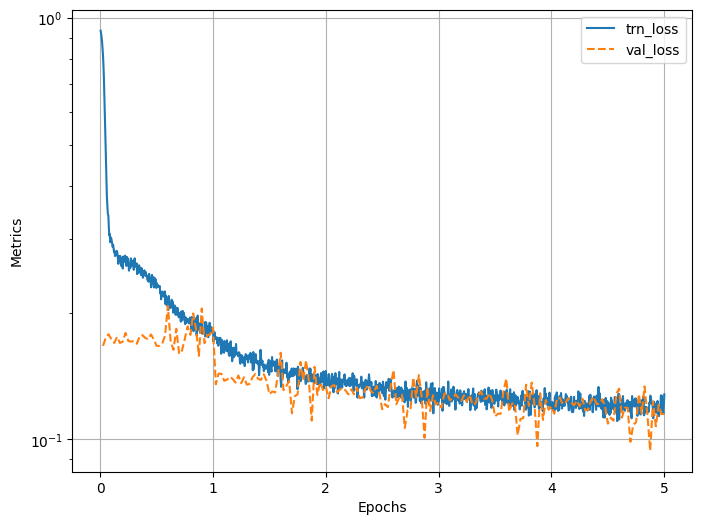

EPOCH: 1.000  trn_loss: 0.239  val_loss: 0.149  (23.85s - 95.39s remaining)
EPOCH: 1.000  trn_loss: 0.239  val_loss: 0.149  (46.78s - 187.12s remaining)
EPOCH: 1.000  trn_loss: 0.239  val_loss: 0.149  (72.80s - 291.20s remaining)
EPOCH: 1.000  trn_loss: 0.239  val_loss: 0.149  (97.44s - 389.76s remaining)
EPOCH: 1.000  trn_loss: 0.239  val_loss: 0.149  (119.93s - 479.71s remaining)


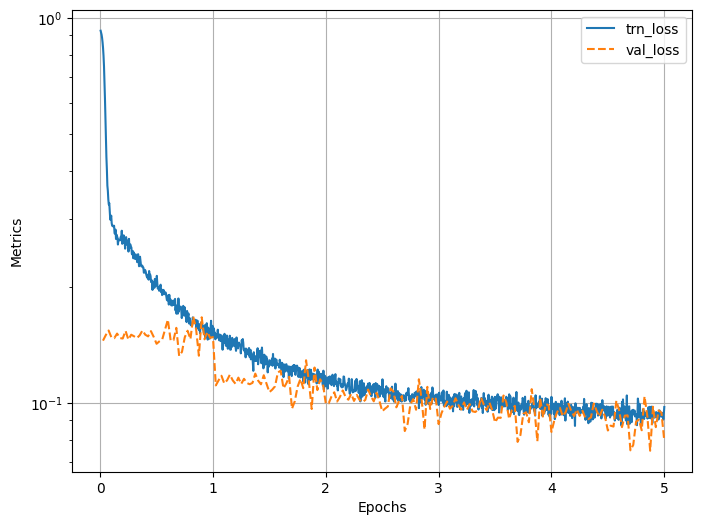

In [11]:
def train_aec(latent_dim):
  model = AutoEncoder(latent_dim).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

  num_epochs = 5
  log = Report(num_epochs)

  for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
      loss = train_batch(data, model, optimizer, criterion)
      log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
      loss = validate_batch(data, model, criterion)
      log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch=1)
  log.plot(log=True)
  return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

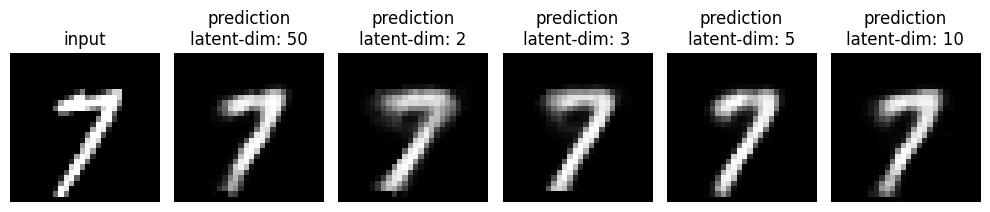

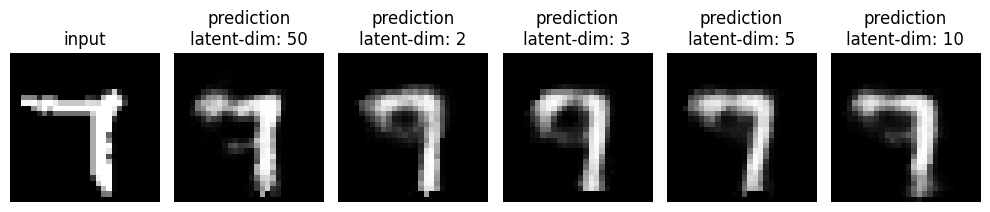

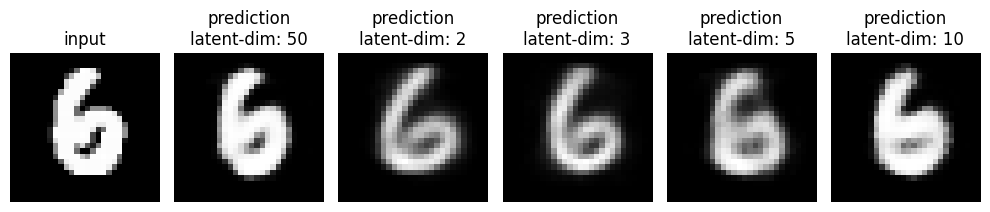

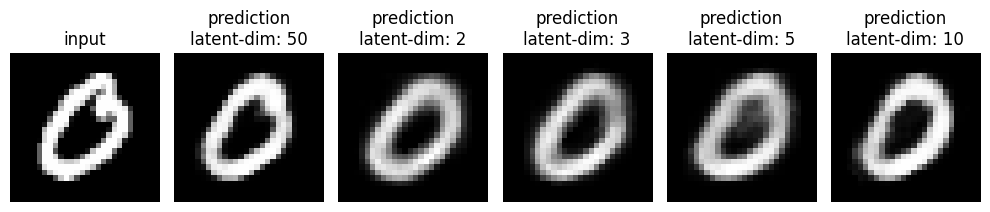

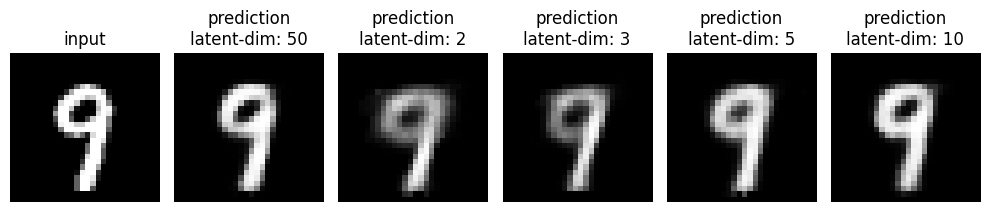

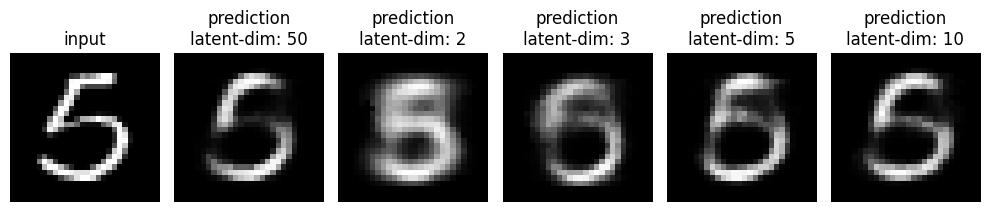

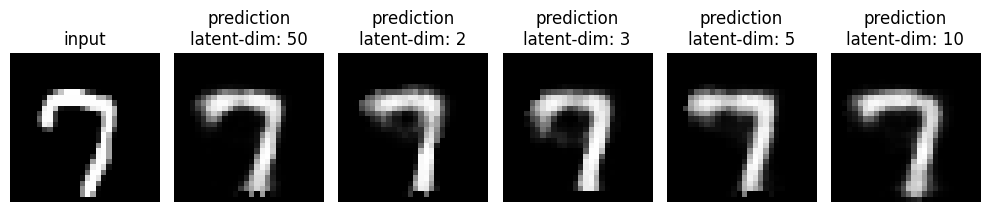

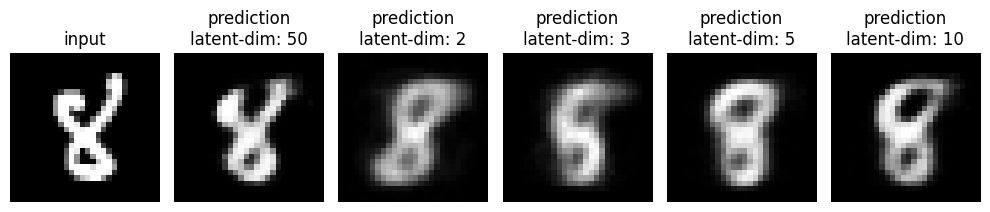

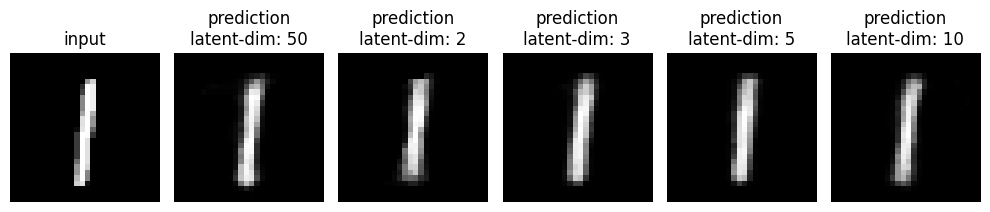

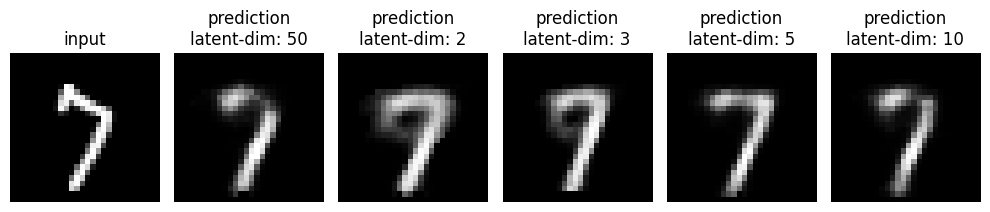

In [12]:
for _ in range(10):
  ix = np.random.randint(len(val_ds))
  im, _ = val_ds[ix]
  fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
  ax = iter(ax.flat)
  show(im[0], ax=next(ax), title='input')
  for model in aecs:
    _im = model(im[None])[0]
    show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim: {model.latent_dim}')
  plt.tight_layout()
  plt.show()